# 22_因果机器学习-双重机器学习：部分线性模型

## Notebook 使用说明

这是因果学习系列的第 12 份，也是“22. 因果机器学习”的第 2 份。建议先阅读《01. 从FWL到Double Lasso》，并熟悉回归、训练集与验证集的区别。本篇需要 NumPy、pandas、Matplotlib、scikit-learn、statsmodels 和 DoubleML：`python -m pip install numpy pandas matplotlib scikit-learn statsmodels doubleml`。

主线依据参考资料 [2] 第 9.2 节与第 9.4 节：用机器学习预测两侧，再用交叉拟合残差构造正交得分。FWL 的线性情形可回看 [1] 附录 B.3。本文用 $T$ 对应第二本书的 $D$，用 $\theta_0$ 对应其第 9.2 节的 $\beta$；书中的 PLM 与软件中的 PLR 在这里都指部分线性回归模型。

12 行小表、非线性主模拟、深树过拟合与弱残差实验均为另设的教学构造，不是原书图 9.1、9.2 的逐数值复现。样条模型、随机森林参数、内层调参和软件核对属于本篇实现；软件接口参考 [3–6]。本次包级核对使用 DoubleML 0.11.4，版本会在初始化单元打印。

所有数据由代码生成，不下载文件，也不依赖前面 Notebook 的变量或辅助模块。主分析的 $T$ 是连续暴露，估计单位暴露变化的恒定效应，不把它叫作二元处理 ATE。默认使用 5 折交叉拟合，在 400 人和 1,600 人两种样本量下各做 400 次独立重复模拟；另外比较同一份数据的不同划分。代码输出和图形均已保存。重新运行请使用 Restart Kernel and Run All Cells，修改参数后以新的输出为准。

In [1]:
# 环境初始化：只生成模拟数据，不读写外部数据文件。
import os
import sys
import tempfile
import warnings
from pathlib import Path
from statistics import NormalDist

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import sklearn
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import statsmodels
import statsmodels.api as sm
# 本篇不使用交互式进度条；只处理缺少可选 IProgress 组件的导入提示。
# 不屏蔽数值、收敛或模型拟合警告。
from tqdm import TqdmWarning
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)
    import doubleml as dml

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 150)

SEED_DATA = 42
SEED_SPLIT = 2026
SEED_REPEAT = 2027
SEED_INNER = 2028
SEED_RESPLIT = 2029
SEED_WEAK = 2030
SEED_LEARNER = 99
N_MAIN = 1200
N_FOLDS = 5
SAMPLE_SIZES = (400, 1600)
N_REPEATS = 400
N_RESPLITS = 20
N_WEAK = 5000
ALPHA_CI = 0.05
Z_CRIT = NormalDist().inv_cdf(1 - ALPHA_CI / 2)

if N_REPEATS < 2 or N_RESPLITS < 2:
    raise ValueError("重复模拟和重新划分都至少需要两次。")
print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__} | statsmodels {statsmodels.__version__} | DoubleML {dml.__version__}")

Python 3.13.9
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
scikit-learn 1.8.0 | statsmodels 0.14.6 | DoubleML 0.11.4


上一篇用 Lasso 去掉控制变量能够解释的部分。现在把这个预测步骤放宽：可以用样条、随机森林，也可以换成其他适合数据的回归器。

但不能只把 `Lasso` 换成 `RandomForestRegressor` 就结束。一棵足够深的树可以把训练集结局完全记住；若拿这些训练预测来算残差，结局残差全为零，后面的“效应”也会变成零。这里需要改变的不只是模型，还包括每个预测是用哪些人训练出来的。

下面先用 12 行数据看清楚“谁训练、谁被预测”，再将同一套步骤放到非线性模拟中。

## 理论基础

### 1. 部分线性，线性的是哪一部分？

模型写成

$$
Y=\theta_0T+g_0(X)+U,\qquad E[U\mid T,X]=0.
$$

$T$ 的系数是一个数，$g_0(X)$ 则可以非线性，也可以依赖很多控制变量。允许 $g_0$ 非线性，并不等于允许 $T$ 的作用任意变化；这里仍有加性、恒定斜率的限制。[2，第 9.2 节]

只有再给出合适的因果识别条件，$\theta_0$ 才具有因果解释。例如，在处理定义清楚、无干扰、一致性、给定处理前 $X$ 后满足条件可忽略性，并有相应支持的情况下，部分线性条件均值模型给出单位暴露变化的平均效应。后面的模拟通过结构方程给出因果解释，并明确所需的条件均值外生性；不把均值条件与完整条件独立性混为一谈。对真实数据，这些条件不是 DML 自动验证的。

如果不采用因果解释，仍可研究残差之间的回归系数。原书备注 9.2.2 也讨论了 PLM 不成立时的残差最佳线性预测系数；不能不加说明地把它称为总体 ATE。

### 2. 先学两个条件均值，而不是先学效应

定义

$$
\ell_0(X)=E[Y\mid X],\qquad m_0(X)=E[T\mid X].
$$

注意 $\ell_0(X)=\theta_0m_0(X)+g_0(X)$，一般不等于 $g_0(X)$。因此，这一步是 `Y ~ X` 和 `T ~ X` 两个预测任务，不是用 `Y ~ T + X` 的拟合值冒充 $\widehat\ell$。[2，定理 9.2.1]

将两侧中可由 $X$ 预测的部分减去：

$$
V=T-m_0(X),\qquad Y-\ell_0(X)=\theta_0V+U.
$$

只要 $E[V^2]>0$，就有

$$
\theta_0=\frac{E[V\{Y-\ell_0(X)\}]}{E[V^2]}.
$$

这是上一篇 FWL 思路的非线性版本。这里的条件均值不必由线性回归估计。[1，附录 B.3；2，定理 9.2.1]

### 3. 交叉拟合：预测第 $i$ 行时，训练中没有第 $i$ 行

将样本分为 $K$ 折。第 $k$ 折只接受预测，其他折用来训练 $\widehat\ell^{(-k)}$ 和 $\widehat m^{(-k)}$。对 $i\in I_k$：

$$
r_{Yi}=Y_i-\widehat\ell^{(-k)}(X_i),\qquad
r_{Ti}=T_i-\widehat m^{(-k)}(X_i).
$$

轮流留出每一折后，每个人恰好有一对折外残差。把所有折外残差合在一起，再计算

$$
\widehat\theta=\frac{\sum_i r_{Ti}r_{Yi}}{\sum_i r_{Ti}^2}.
$$

这对应原书第 9.2 节算法中先产生全部交叉拟合残差、再解一个样本矩方程的做法。不是把每一折的斜率直接取平均；练习一会检查二者的区别。

交叉验证与交叉拟合可以使用相似的分折代码，但目的不同：前者常用验证误差选择超参数，后者把每个人的折外预测放进效应估计。需要调参时，本篇把内层交叉验证也放进外层训练折。外层留出折的 $Y$ 与 $T$ 都不参与对应预测器的拟合或调参。

### 4. 得分为什么要这样写？

令 $W=(Y,T,X)$、$\eta=(\ell,m)$，原书使用的正交得分是

$$
\psi(W;\theta,\eta)=
\{T-m(X)\}\,[Y-\ell(X)-\theta\{T-m(X)\}].
$$

$E[\psi(W;\theta_0,\eta_0)]=0$。实际估计让样本平均得分为零。[2，式 (9.4.3)]

下面的展开是对该公式的计算补充。把两项辅助误差记为 $a(X)=\widehat\ell(X)-\ell_0(X)$、$b(X)=\widehat m(X)-m_0(X)$。将预测器视为在另一份数据上训练好、现在固定的函数，则

$$
E[\psi(W;\theta_0,\widehat\eta)]
=E[b(X)a(X)]-\theta_0E[b(X)^2].
$$

一阶项消失，剩下的是乘积和平方。这是“对小的辅助误差局部不敏感”的含义。它不是说两项误差可以任意大，也不是 AIPW 那句“任意一类模型正确即可”：仅有 $a=0$，右侧通常仍不为零。

原书定理 9.2.2 给出一个充分的质量条件：两项条件均值估计的 $L^2$ 误差都是 $o_p(n^{-1/4})$，并且 $E[V^2]$ 远离零，还需其他正则条件。运行完一个学习器不等于证明满足这些条件。交叉拟合针对的是自身样本噪声进入辅助预测的问题，不会修复未测混杂、错误的效应目标或严重欠拟合。[2，第 9.2、9.4 节]

## 完整案例一：先跟踪 12 行数据

### 1. 列出每一折的训练行与留出行

这张小表只用于看清索引。先使用线性回归作为辅助预测器，分为三折；每折训练 8 行，预测另外 4 行。实际程序中的索引从 0 开始，显示时加 1。

,轮次,训练行,留出行,重叠行数
0,1,"[2, 4, 5, 6, 7, 8, 9, 10]","[1, 3, 11, 12]",0
1,2,"[1, 2, 3, 5, 7, 9, 11, 12]","[4, 6, 8, 10]",0
2,3,"[1, 3, 4, 6, 8, 10, 11, 12]","[2, 5, 7, 9]",0


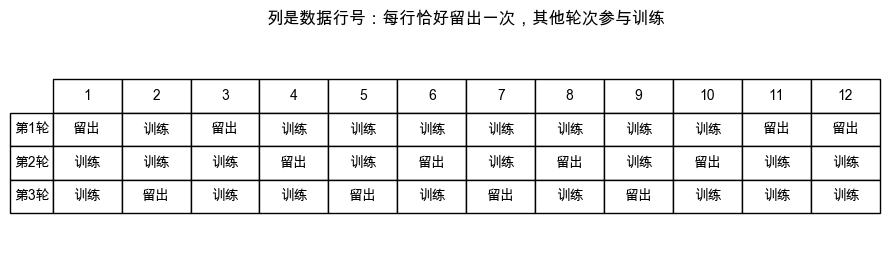

In [2]:
def make_splits(n: int, k: int = N_FOLDS, seed: int = SEED_SPLIT) -> list:
    if not isinstance(n, (int, np.integer)) or not isinstance(k, (int, np.integer)):
        raise TypeError("n 和 k 必须是整数。")
    if not 2 <= k <= n:
        raise ValueError("需要 2 <= 折数 <= 样本量。")
    return list(KFold(n_splits=int(k), shuffle=True, random_state=seed).split(np.arange(n)))


def validate_splits(splits: list, n: int) -> list:
    """要求每折训练/留出互补，所有留出集恰好覆盖一次样本。"""
    if len(splits) < 2:
        raise ValueError("交叉拟合至少需要两折。")
    seen = np.zeros(n, dtype=int)
    checked = []
    for tr, te in splits:
        tr, te = np.asarray(tr), np.asarray(te)
        for idx in (tr, te):
            if idx.ndim != 1 or not np.issubdtype(idx.dtype, np.integer):
                raise ValueError("分折索引必须是一维整数数组。")
            if len(idx) == 0 or len(np.unique(idx)) != len(idx):
                raise ValueError("每个索引集必须非空且不重复。")
            if idx.min() < 0 or idx.max() >= n:
                raise ValueError("分折索引越界。")
        if np.intersect1d(tr, te).size or len(tr) + len(te) != n:
            raise ValueError("训练集和留出集必须互不重叠且互补。")
        seen[te] += 1
        checked.append((tr.copy(), te.copy()))
    if not np.all(seen == 1):
        raise ValueError("每行必须恰好被留出一次。")
    return checked


small = pd.DataFrame({
    "X": [-2.2, -1.8, -1.4, -1.0, -0.6, -0.2, 0.2, 0.6, 1.0, 1.4, 1.8, 2.2],
    "T": [-0.5, -1.5, 0.3, -0.9, 0.8, -0.6, 0.9, -0.4, 1.3, 0.2, 1.7, 0.6],
})
small["Y"] = (1 + 2*small["T"] + 0.7*small["X"]
              + np.array([0.2, -0.3, 0.1, 0.4, -0.2, -0.1, 0.3, -0.4, 0.2, 0.1, -0.3, 0.0]))
small_splits = validate_splits(make_splits(len(small), 3), len(small))
small_audit = pd.DataFrame([
    {"轮次": k+1, "训练行": (tr+1).tolist(), "留出行": (te+1).tolist(),
     "重叠行数": np.intersect1d(tr, te).size}
    for k, (tr, te) in enumerate(small_splits)
])
display(small_audit)

role = np.zeros((3, len(small)), dtype=int)
for k, (_, te) in enumerate(small_splits):
    role[k, te] = 1
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")
role_table = ax.table(
    cellText=[["留出" if role[k, j] else "训练" for j in range(12)] for k in range(3)],
    rowLabels=["第1轮", "第2轮", "第3轮"], colLabels=[str(j+1) for j in range(12)],
    loc="center", cellLoc="center",
)
role_table.auto_set_font_size(False)
role_table.set_fontsize(10)
role_table.scale(1, 1.9)
ax.set_title("列是数据行号：每行恰好留出一次，其他轮次参与训练")
fig.tight_layout()
plt.show()

### 2. 保存折外预测，而不是只保存最后一个模型

循环结束后，保留的不是一套在全体样本上训练的模型，而是每行各自的折外预测。两侧使用同一份外层分折；每折的模型都重新 `clone`，避免继承上一折的拟合状态。

下面的函数同时记录训练误差与留出误差。训练误差只是检查过拟合的参照，不能冒充折外预测质量。样条节点、标准化均值等预处理也应在训练折中确定，稍后会用 Pipeline 保证这一点。[2，第 9.2 节算法；6]

In [3]:
def crossfit_predict(X: np.ndarray, y: np.ndarray, t: np.ndarray,
                     splits: list, ml_l, ml_m) -> dict:
    """返回逐行折外预测、折号、每折模型和训练/留出误差。"""
    X, y, t = np.asarray(X, float), np.asarray(y, float), np.asarray(t, float)
    if X.ndim != 2 or y.ndim != 1 or t.ndim != 1 or len(X) != len(y) or len(y) != len(t):
        raise ValueError("X 必须为矩阵，Y/T 必须为等长一维向量。")
    if not all(np.isfinite(a).all() for a in (X, y, t)):
        raise ValueError("输入含缺失或非有限数值；请先在训练流程中处理。")
    splits = validate_splits(splits, len(y))
    ell_hat, m_hat = np.full(len(y), np.nan), np.full(len(y), np.nan)
    fold = np.full(len(y), -1, dtype=int)
    audit, models = [], []
    for k, (tr, te) in enumerate(splits):
        fit_l = clone(ml_l).fit(X[tr], y[tr])
        fit_m = clone(ml_m).fit(X[tr], t[tr])
        ell_hat[te] = fit_l.predict(X[te])
        m_hat[te] = fit_m.predict(X[te])
        fold[te] = k
        audit.append({
            "折": k+1, "训练人数": len(tr), "留出人数": len(te),
            "重叠人数": np.intersect1d(tr, te).size,
            "Y训练MSE": np.mean((y[tr] - fit_l.predict(X[tr]))**2),
            "Y折外MSE": np.mean((y[te] - ell_hat[te])**2),
            "T训练MSE": np.mean((t[tr] - fit_m.predict(X[tr]))**2),
            "T折外MSE": np.mean((t[te] - m_hat[te])**2),
        })
        models.append((fit_l, fit_m))
    if not np.isfinite(ell_hat).all() or not np.isfinite(m_hat).all():
        raise FloatingPointError("预测含非有限值。")
    return {"ell": ell_hat, "m": m_hat, "fold": fold,
            "audit": pd.DataFrame(audit), "models": models}


small_pred = crossfit_predict(
    small[["X"]].to_numpy(), small["Y"].to_numpy(), small["T"].to_numpy(),
    small_splits, LinearRegression(), LinearRegression()
)
small_trace = small.copy()
small_trace.insert(0, "行号", np.arange(1, len(small)+1))
small_trace["留出折"] = small_pred["fold"] + 1
small_trace["ell_hat"] = small_pred["ell"]
small_trace["m_hat"] = small_pred["m"]
small_trace["rY"] = small["Y"] - small_pred["ell"]
small_trace["rT"] = small["T"] - small_pred["m"]
small_trace["rT*rY"] = small_trace["rT"] * small_trace["rY"]
small_trace["rT^2"] = small_trace["rT"]**2
display(small_trace.round(4))
print("留出次数均为 1；预测已按原始行顺序放回。")

,行号,X,T,Y,留出折,ell_hat,m_hat,rY,rT,rT*rY,rT^2
0,1,-2.2,-0.5,-1.34,1,-3.2681,-1.3048,1.9281,0.8048,1.5516,0.6476
1,2,-1.8,-1.5,-3.56,3,-1.2959,-0.6043,-2.2641,-0.8957,2.0279,0.8022
2,3,-1.4,0.3,0.72,1,-1.7116,-0.8286,2.4316,1.1286,2.7442,1.2737
3,4,-1.0,-0.9,-1.10,2,0.3648,0.0278,-1.4648,-0.9278,1.3590,0.8608
4,5,-0.6,0.8,1.98,3,0.2431,-0.2017,1.7369,1.0017,1.7398,1.0033
5,6,-0.2,-0.6,-0.44,2,1.6672,0.4031,-2.1072,-1.0031,2.1137,1.0062
6,7,0.2,0.9,3.24,3,1.2691,0.0668,1.9709,0.8332,1.6422,0.6943
7,8,0.6,-0.4,0.22,2,2.9696,0.7784,-2.7496,-1.1784,3.2401,1.3886
8,9,1.0,1.3,4.50,3,2.2951,0.3352,2.2049,0.9648,2.1272,0.9308
9,10,1.4,0.2,2.48,2,4.2720,1.1537,-1.7920,-0.9537,1.7090,0.9096


留出次数均为 1；预测已按原始行顺序放回。


### 3. 从两列残差算出系数与标准误

上表最后两列求和后相除，就是系数。小表用来核对计算，不用 12 行数据宣称区间已具有良好覆盖率。

对后面较大的独立同分布样本，按原书的得分方法计算不确定性。记

$$
\widehat Q=\frac1n\sum_i r_{Ti}^2,\quad
\widehat\psi_i=r_{Ti}(r_{Yi}-\widehat\theta r_{Ti}),\quad
\widehat\varphi_i=\frac{\widehat\psi_i}{\widehat Q}.
$$

这里 $\partial_\theta\overline\psi=-\widehat Q$，因此 $-\widehat J^{-1}\widehat\psi_i=\widehat\psi_i/\widehat Q$。近似标准误与区间为

$$
\widehat{\mathrm{SE}}=
\sqrt{\frac{1}{n^2}\sum_i\widehat\varphi_i^2},\qquad
\widehat\theta\pm z_{0.975}\widehat{\mathrm{SE}}.
$$

得分均值在求根后为零，所以此处均方与中心化方差相同。它也等于对这两列残差做无截距 OLS 后的 HC0 标准误。[2，第 9.4 节步骤 4–6；4]

折外残差不一定严格以零为样本均值。本篇不再额外中心化、不加截距，以保持与上面的矩方程和软件得分一致。所有折外残差是合起来求根，不将不同折当作独立的研究来合并。

In [4]:
def plr_score(y: np.ndarray, t: np.ndarray,
              ell_hat: np.ndarray, m_hat: np.ndarray) -> dict:
    values = [np.asarray(a, dtype=float) for a in (y, t, ell_hat, m_hat)]
    if any(a.ndim != 1 for a in values) or len({len(a) for a in values}) != 1:
        raise ValueError("四项输入必须是等长一维向量。")
    if len(values[0]) < 3 or not all(np.isfinite(a).all() for a in values):
        raise ValueError("至少需要 3 行有限数值。")
    y, t, ell_hat, m_hat = values
    r_y, r_t = y - ell_hat, t - m_hat
    n = len(y)
    q = float(np.mean(r_t**2))
    # 这里只拦截数值退化，不把“通过阈值”当成强识别的检验。
    tolerance = 100*np.finfo(float).eps*max(1.0, float(np.mean(t**2)))
    if q <= tolerance:
        raise ValueError("处理残差几乎为零，无法从该残差回归中识别系数。")
    theta = float(np.mean(r_t*r_y) / q)
    u_hat = r_y - theta*r_t
    psi = r_t*u_hat
    phi = psi/q
    se = float(np.sqrt(np.mean(phi**2)/n))
    # 同方差版本只用于后面的反例对照；正式区间采用上面的 HC0。
    se_homosked = float(np.sqrt(np.sum(u_hat**2)/(n-1)/np.sum(r_t**2)))
    return {"theta": theta, "se": se, "lo": theta-Z_CRIT*se, "hi": theta+Z_CRIT*se,
            "q": q, "psi": psi, "phi": phi, "r_y": r_y, "r_t": r_t,
            "se_homosked": se_homosked}


small_result = plr_score(small["Y"].to_numpy(), small["T"].to_numpy(),
                         small_pred["ell"], small_pred["m"])
by_columns = small_trace["rT*rY"].sum() / small_trace["rT^2"].sum()
assert np.isclose(by_columns, small_result["theta"])
print(f"分子合计 = {small_trace['rT*rY'].sum():.6f}")
print(f"分母合计 = {small_trace['rT^2'].sum():.6f}")
print(f"三折交叉拟合系数 = {small_result['theta']:.6f}")
print(f"样本平均得分 = {small_result['psi'].mean():.3e}")

分子合计 = 21.891310
分母合计 = 10.416415
三折交叉拟合系数 = 2.101617
样本平均得分 = -5.360e-16


## 完整案例二：非线性控制与异方差

### 1. 给出能查看真值的生成过程

这次另设六个独立的 $X_j\sim\mathrm{Uniform}(-2,2)$，其中后两个只是候选噪声变量。令 $V_0,E$ 为相互独立、也独立于 $X$ 的标准正态变量：

$$
\begin{aligned}
m_0(X)&=0.8\sin(\pi X_1/2)+0.6(X_2^2-4/3)+0.4X_3,\\
g_0(X)&=1.5\sin(\pi X_1/2)+(X_2^2-4/3)+0.6X_4,\\
T&=m_0(X)+V_0,\\
U&=(0.5+0.5|V_0|)E,\\
Y&=1\cdot T+g_0(X)+U.
\end{aligned}
$$

真值为 $\theta_0=1$。$X_1,X_2$ 同时影响暴露和结局；只对原始 $X$ 作线性调整，会漏掉非线性共同变化。$U$ 的方差随 $V_0$ 改变，但条件均值仍为零，所以保留了部分线性模型的外生性条件。

因果模拟也可以写为 $Y(t)=t+g_0(X)+U$。给定 $X$ 后，$U$ 与暴露的条件均值关系足以识别这里的恒定平均斜率；不过二者并非条件独立，因为误差方差随 $V_0$ 改变。因此这个具体生成式使用的是条件均值外生性，不声称满足潜在结局与处理的完整条件独立。两种条件不要混为一谈。

函数分别返回观察表与真值字典。只有观察表进入可实施估计，真值字典用于评价和“已知辅助函数”的参照计算。

,X1,X2,X3,X4,X5,X6,T,Y
0,1.096,-0.244,1.434,0.789,-1.623,1.902,1.368,3.621
1,1.045,1.144,-1.488,-0.198,-0.517,1.707,0.230,2.056
2,0.575,1.291,-0.226,-1.091,0.218,-1.745,2.230,2.563
3,1.311,0.527,1.032,-0.582,1.883,1.572,1.777,2.357
4,1.114,-1.221,-0.133,-1.825,-1.383,0.732,1.026,0.754
5,0.979,1.870,-0.697,-0.518,-0.122,-1.242,1.557,4.484


样本量 = 1200；候选控制变量 = 6；真实单位暴露效应 = 1.0
缺失值总数 = 0


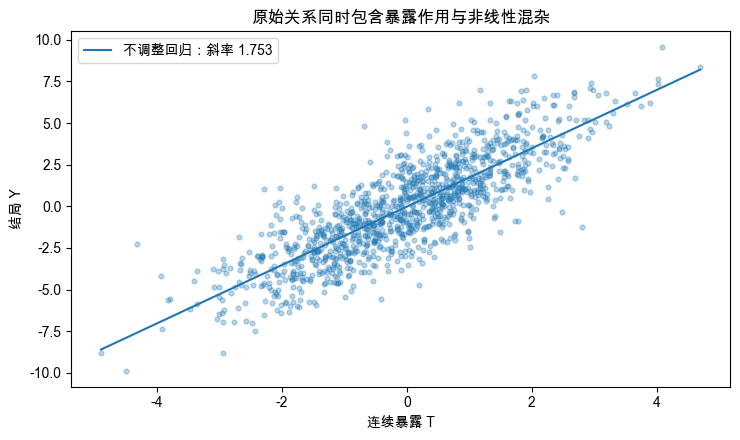

In [5]:
def generate_data(n: int, seed, *, p: int = 6, treatment_noise: float = 1.0):
    if not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError("n 必须为不小于 20 的整数。")
    if not isinstance(p, (int, np.integer)) or p < 4:
        raise ValueError("本生成式至少需要 4 个协变量。")
    if not np.isfinite(treatment_noise) or treatment_noise < 0:
        raise ValueError("暴露噪声尺度必须是非负有限数。")
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, size=(n, p))
    m = 0.8*np.sin(np.pi*X[:, 0]/2) + 0.6*(X[:, 1]**2 - 4/3) + 0.4*X[:, 2]
    g = 1.5*np.sin(np.pi*X[:, 0]/2) + (X[:, 1]**2 - 4/3) + 0.6*X[:, 3]
    v0 = rng.normal(size=n)
    u = (0.5 + 0.5*np.abs(v0))*rng.normal(size=n)
    t = m + treatment_noise*v0
    y = t + g + u
    frame = pd.DataFrame(X, columns=[f"X{j+1}" for j in range(p)])
    frame["T"], frame["Y"] = t, y
    truth = {"theta": 1.0, "m": m, "g": g, "ell": m+g,
             "v": treatment_noise*v0, "u": u}
    return frame, truth


main, truth = generate_data(N_MAIN, SEED_DATA)
X_COLS = [c for c in main if c.startswith("X")]
X = main[X_COLS].to_numpy()
y, t = main["Y"].to_numpy(), main["T"].to_numpy()
splits = make_splits(len(main))
display(main.head(6).round(3))
print(f"样本量 = {len(main)}；候选控制变量 = {len(X_COLS)}；真实单位暴露效应 = {truth['theta']:.1f}")
print("缺失值总数 =", int(main.isna().sum().sum()))

raw_fit = sm.OLS(y, sm.add_constant(t)).fit(cov_type="HC0")
xline = np.linspace(t.min(), t.max(), 100)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(t, y, s=12, alpha=0.3)
ax.plot(xline, raw_fit.params[0] + raw_fit.params[1]*xline,
        label=f"不调整回归：斜率 {raw_fit.params[1]:.3f}")
ax.set(xlabel="连续暴露 T", ylabel="结局 Y", title="原始关系同时包含暴露作用与非线性混杂")
ax.legend()
fig.tight_layout()
plt.show()

### 2. 把完整的预测流程放在每个训练折里

先用“加性三次样条＋Ridge”。样条将每列 $X$ 展开成局部基函数，再用 Ridge 拟合；它比直接的直线灵活，但本实现没有加入变量间交互。主生成式是加性的，所以这是一个有意匹配结构的教学基准，不是通用最优学习器。[6]

节点数 5、Ridge 惩罚 1 都在分析前固定。后面另做内层调参示范，不根据这里已知的 $\theta_0$ 调整模型。固定节点的样条还可能留下逼近误差；有限次模拟不能代替渐近速率的证明。

In [6]:
def make_spline(alpha: float = 1.0):
    if not np.isfinite(alpha) or alpha <= 0:
        raise ValueError("Ridge alpha 必须为正的有限数。")
    return make_pipeline(
        SplineTransformer(n_knots=5, degree=3, include_bias=False, knots="uniform"),
        StandardScaler(),
        Ridge(alpha=alpha),
    )


spline_pred = crossfit_predict(X, y, t, splits, make_spline(), make_spline())
display(spline_pred["audit"].round(4))
trace = pd.DataFrame({
    "折": spline_pred["fold"] + 1, "Y": y, "T": t,
    "ell_hat": spline_pred["ell"], "m_hat": spline_pred["m"],
    "rY": y-spline_pred["ell"], "rT": t-spline_pred["m"],
})
display(trace.head(8).round(4))
# 以第一折为例，标准化均值来自该折的训练数据，而不是全体数据。
first_tr, _ = splits[0]
first_model = spline_pred["models"][0][0]
first_basis = first_model.named_steps["splinetransformer"].transform(X[first_tr])
np.testing.assert_allclose(first_model.named_steps["standardscaler"].mean_, first_basis.mean(axis=0))
print("第一折的预处理拟合范围已核对。")

,折,训练人数,留出人数,重叠人数,Y训练MSE,Y折外MSE,T训练MSE,T折外MSE
0,1,960,240,0,1.8875,1.9165,0.9542,0.9104
1,2,960,240,0,1.8306,2.1744,0.9266,1.0347
2,3,960,240,0,1.9219,1.7946,0.9341,0.9902
3,4,960,240,0,1.9193,1.7965,0.9516,0.9284
4,5,960,240,0,1.7996,2.2602,0.9062,1.1111


,折,Y,T,ell_hat,m_hat,rY,rT
0,2,3.6208,1.3679,1.4038,0.6071,2.2169,0.7609
1,1,2.0557,0.2305,1.5499,0.2052,0.5058,0.0252
2,2,2.5629,2.2297,1.8710,0.9560,0.6920,1.2738
3,4,2.3569,1.7770,0.3812,0.5649,1.9757,1.2121
4,5,0.7545,1.0262,1.2808,0.6964,-0.5263,0.3298
5,2,4.4843,1.5568,5.0665,1.9572,-0.5822,-0.4004
6,2,-3.2379,-1.3076,-3.5506,-1.8817,0.3128,0.5741
7,4,2.3061,0.6504,2.2126,0.6748,0.0934,-0.0244


第一折的预处理拟合范围已核对。


### 3. 残差、得分与推断

现在只对上表中的 `rY` 与 `rT` 作计算。下面再通过 statsmodels 的无截距 OLS 核对系数与 HC0 标准误，并展示逐行得分和影响函数值。

影响函数绝对值大，表示该行对一阶抽样波动的贡献较大；它不是这一行的个体处理效应。样本平均得分接近零只是因为我们解了这个方程，不是无混杂、辅助模型正确或因果识别成立的检验。

,折,Y,T,ell_hat,m_hat,rY,rT,psi,phi
0,2,3.6208,1.3679,1.4038,0.6071,2.2169,0.7609,1.0847,1.0902
1,1,2.0557,0.2305,1.5499,0.2052,0.5058,0.0252,0.0121,0.0122
2,2,2.5629,2.2297,1.8710,0.9560,0.6920,1.2738,-0.8060,-0.8101
3,4,2.3569,1.7770,0.3812,0.5649,1.9757,1.2121,0.8668,0.8712
4,5,0.7545,1.0262,1.2808,0.6964,-0.5263,0.3298,-0.2867,-0.2882
5,2,4.4843,1.5568,5.0665,1.9572,-0.5822,-0.4004,0.0664,0.0667
6,2,-3.2379,-1.3076,-3.5506,-1.8817,0.3128,0.5741,-0.1633,-0.1641
7,4,2.3061,0.6504,2.2126,0.6748,0.0934,-0.0244,-0.0029,-0.0029


theta = 1.040026；HC0 SE = 0.035860
95% CI = [0.969741, 1.110311]
Q = 0.994934；平均得分 = -1.480e-16
同方差 SE（仅作对照）= 0.027654


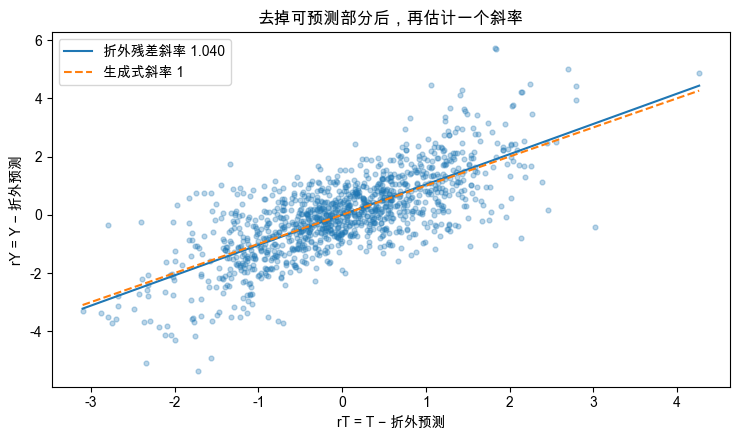

In [7]:
spline_result = plr_score(y, t, spline_pred["ell"], spline_pred["m"])
oracle_result = plr_score(y, t, truth["ell"], truth["m"])
residual_ols = sm.OLS(spline_result["r_y"], spline_result["r_t"][:, None]).fit(cov_type="HC0")
np.testing.assert_allclose(residual_ols.params[0], spline_result["theta"], rtol=1e-12)
np.testing.assert_allclose(residual_ols.bse[0], spline_result["se"], rtol=1e-12)

score_table = trace.head(8).copy()
score_table["psi"] = spline_result["psi"][:8]
score_table["phi"] = spline_result["phi"][:8]
display(score_table.round(4))
print(f"theta = {spline_result['theta']:.6f}；HC0 SE = {spline_result['se']:.6f}")
print(f"95% CI = [{spline_result['lo']:.6f}, {spline_result['hi']:.6f}]")
print(f"Q = {spline_result['q']:.6f}；平均得分 = {spline_result['psi'].mean():.3e}")
print(f"同方差 SE（仅作对照）= {spline_result['se_homosked']:.6f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(spline_result["r_t"], spline_result["r_y"], s=12, alpha=0.3)
vline = np.linspace(spline_result["r_t"].min(), spline_result["r_t"].max(), 100)
ax.plot(vline, spline_result["theta"]*vline, label=f"折外残差斜率 {spline_result['theta']:.3f}")
ax.plot(vline, truth["theta"]*vline, linestyle="--", label="生成式斜率 1")
ax.set(xlabel="rT = T − 折外预测", ylabel="rY = Y − 折外预测", title="去掉可预测部分后，再估计一个斜率")
ax.legend()
fig.tight_layout()
plt.show()

### 4. 同一份数据比较几种做法

下面比较不调整回归、只对原始变量作线性残差化、同样本样条残差化、交叉拟合样条和交叉拟合随机森林。再加一项“深树预测 $Y$、样条预测 $T$”，为后面的过拟合实验作准备。

每个方法使用相同的观察表；所有交叉拟合方法使用相同分折。原书第 9.2 节允许两侧使用不同学习器，这里正好可以看到两侧预测任务不必采用同一模型。已知辅助函数只作模拟参照，实际研究没有这项输入。[2，第 9.2 节]

,估计值,标准误,下限,上限
方法,,,,
不调整,1.7533,0.0350,1.6846,1.8219
线性：交叉拟合,1.6766,0.0343,1.6094,1.7438
样条：同样本,1.0419,0.0359,0.9716,1.1122
样条：交叉拟合,1.0400,0.0359,0.9697,1.1103
森林：交叉拟合,1.0738,0.0388,0.9977,1.1498
深树Y：交叉拟合,0.9629,0.0624,0.8405,1.0853
已知辅助函数,1.0424,0.0372,0.9694,1.1154


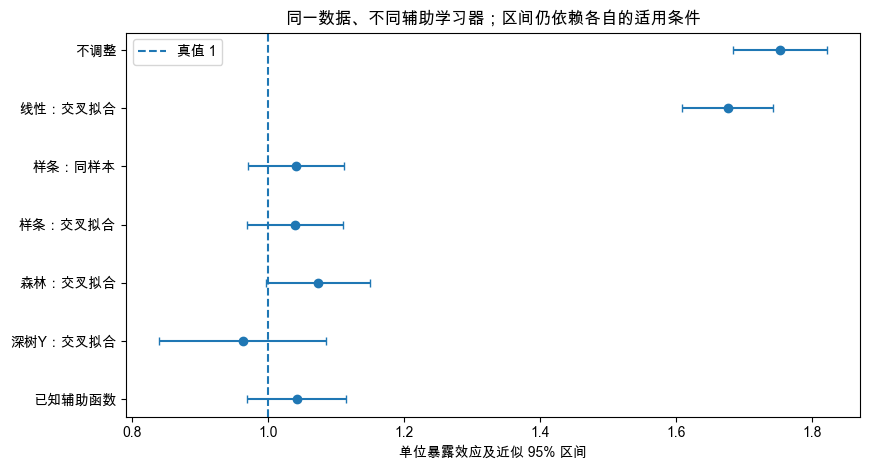

In [8]:
linear_pred = crossfit_predict(X, y, t, splits, LinearRegression(), LinearRegression())
forest = RandomForestRegressor(
    n_estimators=100, min_samples_leaf=8, max_features=1.0,
    random_state=SEED_LEARNER, n_jobs=1,
)
forest_pred = crossfit_predict(X, y, t, splits, forest, forest)
deep_tree = DecisionTreeRegressor(random_state=SEED_LEARNER)
tree_pred = crossfit_predict(X, y, t, splits, deep_tree, make_spline())
full_l, full_m = make_spline().fit(X, y), make_spline().fit(X, t)

main_results = {
    "不调整": {"theta": float(raw_fit.params[1]), "se": float(raw_fit.bse[1])},
    "线性：交叉拟合": plr_score(y, t, linear_pred["ell"], linear_pred["m"]),
    "样条：同样本": plr_score(y, t, full_l.predict(X), full_m.predict(X)),
    "样条：交叉拟合": spline_result,
    "森林：交叉拟合": plr_score(y, t, forest_pred["ell"], forest_pred["m"]),
    "深树Y：交叉拟合": plr_score(y, t, tree_pred["ell"], tree_pred["m"]),
    "已知辅助函数": oracle_result,
}
main_summary = pd.DataFrame([
    {"方法": name, "估计值": r["theta"], "标准误": r["se"],
     "下限": r["theta"]-Z_CRIT*r["se"], "上限": r["theta"]+Z_CRIT*r["se"]}
    for name, r in main_results.items()
]).set_index("方法")
display(main_summary.round(4))
fig, ax = plt.subplots(figsize=(8.8, 4.8))
pos = np.arange(len(main_summary))
ax.errorbar(main_summary["估计值"], pos, xerr=Z_CRIT*main_summary["标准误"], fmt="o", capsize=3)
ax.axvline(truth["theta"], linestyle="--", label="真值 1")
ax.set(yticks=pos, yticklabels=main_summary.index, xlabel="单位暴露效应及近似 95% 区间",
       title="同一数据、不同辅助学习器；区间仍依赖各自的适用条件")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

默认样本中，不调整斜率约为 1.753，只作线性残差化仍为 1.677；样条交叉拟合为 1.040，森林为 1.074。样条的 HC0 标准误约为 0.036，而同方差版本只有约 0.028。

这张表不能用来选“最接近 1”的学习器，因为在真实数据中并不知道 1。应先检查辅助预测是否捕捉了数据结构，再通过独立模拟了解某种流程的表现。

同样本样条与交叉拟合样条可以很接近。交叉拟合不是保证每一份数据的点估计更接近真值；当模型复杂度有限、过拟合较轻时，不一定出现明显差别。深树的例子会显示另一种情况。

### 5. 预测误差检查的对象是什么？

折外 RMSE 是对观察到的 $Y$ 或 $T$ 的误差，包含无法由 $X$ 预测的噪声。模拟中还能另外计算 $\widehat\ell$ 对 $\ell_0$、$\widehat m$ 对 $m_0$ 的误差；这才直接对应辅助函数误差，但真实数据通常无法算出。

这两组量不能混用。这里只检查预测，不用 RMSE 或 $R^2$ 证明条件均值外生性。

,Y训练RMSE,Y折外RMSE,T训练RMSE,T折外RMSE,ell真值RMSE,m真值RMSE
学习器,,,,,,
线性,2.5006,2.5136,1.2437,1.2499,2.1187,0.7882
样条,1.3681,1.4101,0.9667,0.9975,0.2786,0.1864
森林,1.2078,1.5677,0.7893,1.0205,0.7501,0.3633
深树Y＋样条T,0.0000,2.1885,0.9667,0.9975,1.6800,0.1864


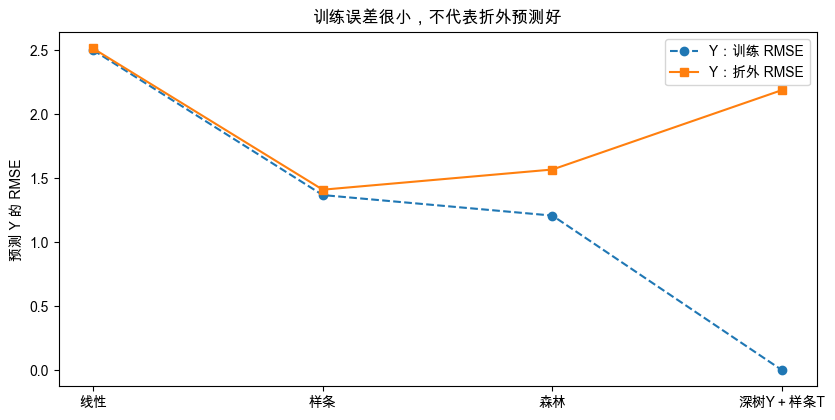

In [9]:
prediction_results = {
    "线性": linear_pred, "样条": spline_pred,
    "森林": forest_pred, "深树Y＋样条T": tree_pred,
}
prediction_rows = []
for name, pr in prediction_results.items():
    audit = pr["audit"]
    prediction_rows.append({
        "学习器": name,
        "Y训练RMSE": np.sqrt(np.average(audit["Y训练MSE"], weights=audit["训练人数"])),
        "Y折外RMSE": np.sqrt(np.mean((y-pr["ell"])**2)),
        "T训练RMSE": np.sqrt(np.average(audit["T训练MSE"], weights=audit["训练人数"])),
        "T折外RMSE": np.sqrt(np.mean((t-pr["m"])**2)),
        "ell真值RMSE": np.sqrt(np.mean((truth["ell"]-pr["ell"])**2)),
        "m真值RMSE": np.sqrt(np.mean((truth["m"]-pr["m"])**2)),
    })
prediction_table = pd.DataFrame(prediction_rows).set_index("学习器")
display(prediction_table.round(4))
fig, ax = plt.subplots(figsize=(8.5, 4.3))
p = np.arange(len(prediction_table))
ax.plot(p, prediction_table["Y训练RMSE"], "o--", label="Y：训练 RMSE")
ax.plot(p, prediction_table["Y折外RMSE"], "s-", label="Y：折外 RMSE")
ax.set(xticks=p, xticklabels=prediction_table.index, ylabel="预测 Y 的 RMSE",
       title="训练误差很小，不代表折外预测好")
ax.legend()
fig.tight_layout()
plt.show()

## 软件核对：将同一分折交给 DoubleML

这里的重点不是多调用一次 `fit()`，而是让两种实现真正比较同一件事：同一数据、同一特征列、同一学习器参数、同一分折、同一个 `partialling out` 得分。使用一次分折，即 `n_rep=1`，避免把重复划分的聚合与单次计算混在一起。[3、5]

DoubleML 将得分记为 $\psi_a\theta+\psi_b$，这里对应 $\psi_a=-r_T^2$、$\psi_b=r_Tr_Y$。本篇直接核对预测向量、这两个得分分量、最终系数和标准误，不只看打印结果是否“大致接近”。[4]

In [10]:
dml_data = dml.DoubleMLData(main, y_col="Y", d_cols="T", x_cols=X_COLS)
package_checks = []
package_models = {}
for name, learner, manual_pred, manual_result in [
    ("样条", make_spline(), spline_pred, spline_result),
    ("森林", forest, forest_pred, main_results["森林：交叉拟合"]),
]:
    model = dml.DoubleMLPLR(
        dml_data, ml_l=clone(learner), ml_m=clone(learner),
        n_folds=N_FOLDS, n_rep=1, score="partialling out", draw_sample_splitting=False,
    )
    model.set_sample_splitting(splits)
    model.fit(n_jobs_cv=1, store_predictions=True)
    library_l = model.predictions["ml_l"][:, 0, 0]
    library_m = model.predictions["ml_m"][:, 0, 0]
    np.testing.assert_allclose(library_l, manual_pred["ell"], rtol=1e-11, atol=1e-11)
    np.testing.assert_allclose(library_m, manual_pred["m"], rtol=1e-11, atol=1e-11)
    np.testing.assert_allclose(model.psi_elements["psi_a"][:, 0, 0], -manual_result["r_t"]**2)
    np.testing.assert_allclose(model.psi_elements["psi_b"][:, 0, 0],
                               manual_result["r_t"]*manual_result["r_y"])
    np.testing.assert_allclose(model.coef[0], manual_result["theta"], rtol=1e-11)
    np.testing.assert_allclose(model.se[0], manual_result["se"], rtol=1e-11)
    package_checks.append({
        "学习器": name, "手写系数": manual_result["theta"], "DoubleML系数": model.coef[0],
        "手写SE": manual_result["se"], "DoubleML_SE": model.se[0],
        "ell最大差": np.max(np.abs(library_l-manual_pred["ell"])),
        "m最大差": np.max(np.abs(library_m-manual_pred["m"])),
    })
    package_models[name] = model
package_comparison = pd.DataFrame(package_checks).set_index("学习器")
display(package_comparison.round(10))
print("两种学习器的预测、得分、系数与标准误均通过数值核对。")

,手写系数,DoubleML系数,手写SE,DoubleML_SE,ell最大差,m最大差
学习器,,,,,,
样条,1.040026,1.040026,0.035860,0.035860,0.0,0.0
森林,1.073776,1.073776,0.038791,0.038791,0.0,0.0


两种学习器的预测、得分、系数与标准误均通过数值核对。


## 模型分析

### 1. 重新抽样，而不是反复划分同一份数据

每次模拟都重新生成 $X,T,Y$，再重新拟合所有辅助模型。两种样本量采用相同的生成机制，不沿用主样本的预测或系数。每份数据内部各方法共用分折，以便比较。

重复模拟集中比较线性、样条和深树三种结构，随机森林保留在上面的单样本与软件核对中，不根据一次森林结果概括它的整体表现。样条仍使用事先固定的节点和惩罚。

另外对已知辅助函数的相同系数分别使用 HC0 与同方差标准误。这个对照不涉及学习器质量，单独检查异方差时的区间计算。

In [11]:
def simulate_one(n: int, seed: int) -> list:
    frame, known = generate_data(n, seed)
    xx = frame.filter(regex="^X").to_numpy()
    yy, tt = frame["Y"].to_numpy(), frame["T"].to_numpy()
    smpls = make_splits(n, N_FOLDS, seed+1)
    pr_s = crossfit_predict(xx, yy, tt, smpls, make_spline(), make_spline())
    pr_l = crossfit_predict(xx, yy, tt, smpls, LinearRegression(), LinearRegression())
    # 只需另外拟合 Y 的深树，T 的样条折外预测直接复用同一分折的结果。
    tree_l = np.empty(n)
    for tr, te in smpls:
        tree_l[te] = DecisionTreeRegressor(random_state=SEED_LEARNER).fit(xx[tr], yy[tr]).predict(xx[te])
    fit_l, fit_m = make_spline().fit(xx, yy), make_spline().fit(xx, tt)
    estimates = {
        "线性：交叉拟合": plr_score(yy, tt, pr_l["ell"], pr_l["m"]),
        "样条：同样本": plr_score(yy, tt, fit_l.predict(xx), fit_m.predict(xx)),
        "样条：交叉拟合": plr_score(yy, tt, pr_s["ell"], pr_s["m"]),
        "深树Y：交叉拟合": plr_score(yy, tt, tree_l, pr_s["m"]),
        "已知函数：HC0": plr_score(yy, tt, known["ell"], known["m"]),
    }
    oracle = estimates["已知函数：HC0"]
    estimates["已知函数：同方差"] = {"theta": oracle["theta"], "se": oracle["se_homosked"]}
    return [
        {"n": n, "方法": name, "估计": r["theta"], "标准误": r["se"],
         "误差": r["theta"]-known["theta"],
         "覆盖": abs(r["theta"]-known["theta"]) <= Z_CRIT*r["se"]}
        for name, r in estimates.items()
    ]


simulation_rows = []
for size_index, n in enumerate(SAMPLE_SIZES):
    for r in range(N_REPEATS):
        seed = SEED_REPEAT + 100_000*size_index + 10*r
        simulation_rows.extend(simulate_one(n, seed))
simulation = pd.DataFrame(simulation_rows)
print(f"完成 {len(SAMPLE_SIZES)} × {N_REPEATS} = {len(SAMPLE_SIZES)*N_REPEATS} 份独立数据的分析。")
print("每份数据均重新生成并重新拟合；未跳过失败样本。")

完成 2 × 400 = 800 份独立数据的分析。
每份数据均重新生成并重新拟合；未跳过失败样本。


,n,方法,偏差,偏差MCSE,经验SD,平均SE,RMSE,覆盖率
0,400,线性：交叉拟合,0.6661,0.0030,0.0608,0.0602,0.6689,0.0000
1,400,样条：同样本,0.0058,0.0034,0.0674,0.0637,0.0676,0.9475
2,400,样条：交叉拟合,0.0052,0.0035,0.0692,0.0631,0.0693,0.9200
3,400,深树Y：交叉拟合,-0.0483,0.0054,0.1076,0.1064,0.1178,0.9125
4,400,已知函数：HC0,0.0026,0.0033,0.0661,0.0662,0.0661,0.9575
5,400,已知函数：同方差,0.0026,0.0033,0.0661,0.0473,0.0661,0.8200
6,1600,线性：交叉拟合,0.6635,0.0014,0.0272,0.0304,0.6641,0.0000
7,1600,样条：同样本,-0.0005,0.0015,0.0299,0.0330,0.0298,0.9750
8,1600,样条：交叉拟合,-0.0001,0.0015,0.0301,0.0329,0.0300,0.9700
9,1600,深树Y：交叉拟合,-0.0102,0.0026,0.0512,0.0522,0.0522,0.9600


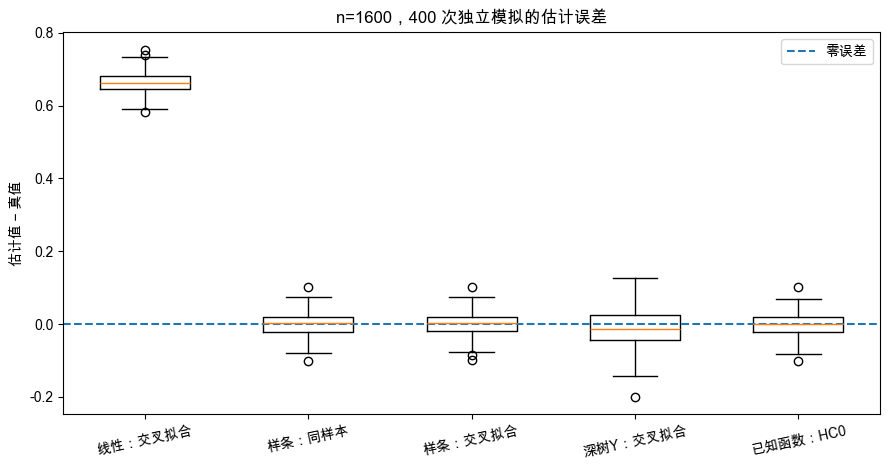

In [12]:
def wilson_interval(successes: int, total: int, z: float = Z_CRIT) -> tuple:
    if total < 1 or not 0 <= successes <= total:
        raise ValueError("成功次数应在 0 到总次数之间。")
    p = successes/total
    denominator = 1+z*z/total
    center = (p+z*z/(2*total))/denominator
    half = z*np.sqrt(p*(1-p)/total+z*z/(4*total*total))/denominator
    return center-half, center+half


METHOD_ORDER = ["线性：交叉拟合", "样条：同样本", "样条：交叉拟合", "深树Y：交叉拟合",
                "已知函数：HC0", "已知函数：同方差"]
summary_rows = []
for n in SAMPLE_SIZES:
    for name in METHOD_ORDER:
        part = simulation.loc[(simulation["n"] == n) & (simulation["方法"] == name)]
        errors = part["误差"].to_numpy()
        success, R = int(part["覆盖"].sum()), len(part)
        lo, hi = wilson_interval(success, R)
        summary_rows.append({
            "n": n, "方法": name, "偏差": errors.mean(),
            "偏差MCSE": errors.std(ddof=1)/np.sqrt(R),
            "经验SD": part["估计"].std(ddof=1), "平均SE": part["标准误"].mean(),
            "RMSE": np.sqrt(np.mean(errors**2)), "覆盖率": success/R,
            "覆盖次数": success, "覆盖率下限": lo, "覆盖率上限": hi,
        })
simulation_summary = pd.DataFrame(summary_rows)
display(simulation_summary[["n", "方法", "偏差", "偏差MCSE", "经验SD", "平均SE", "RMSE", "覆盖率"]].round(4))

# 两种已知函数方法的点估计相同，故分布图只画一次。
plot_methods = METHOD_ORDER[:-1]
large_n = max(SAMPLE_SIZES)
distributions = [simulation.loc[(simulation["n"] == large_n) & (simulation["方法"] == name), "误差"]
                 for name in plot_methods]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.boxplot(distributions, tick_labels=plot_methods, showfliers=True, widths=0.55)
ax.axhline(0, linestyle="--", label="零误差")
ax.set(ylabel="估计值 − 真值", title=f"n={large_n}，{N_REPEATS} 次独立模拟的估计误差")
ax.tick_params(axis="x", labelrotation=12)
ax.legend()
fig.tight_layout()
plt.show()

默认模拟中，线性交叉拟合在两种样本量下的偏差都约为 0.66，800 个区间均未覆盖真值。样条交叉拟合的平均偏差分别约为 0.005 和 0.000；深树 Y 版本分别约为 −0.048 和 −0.010，且波动更大。

线性残差化遗漏的是生成式中的函数结构，增加样本量不会自动补回正弦项和二次项。深树虽然经过交叉拟合，但单棵树预测 $Y$ 的误差较大，可能使效应估计更不稳定；交叉拟合与提高预测质量是两件事。

表中的“偏差 MCSE”是平均误差自身的 Monte Carlo 标准误，不是某一次研究的标准误。下面覆盖率旁的短线也是有限次模拟带来的二项比例不确定性，不是效应区间。

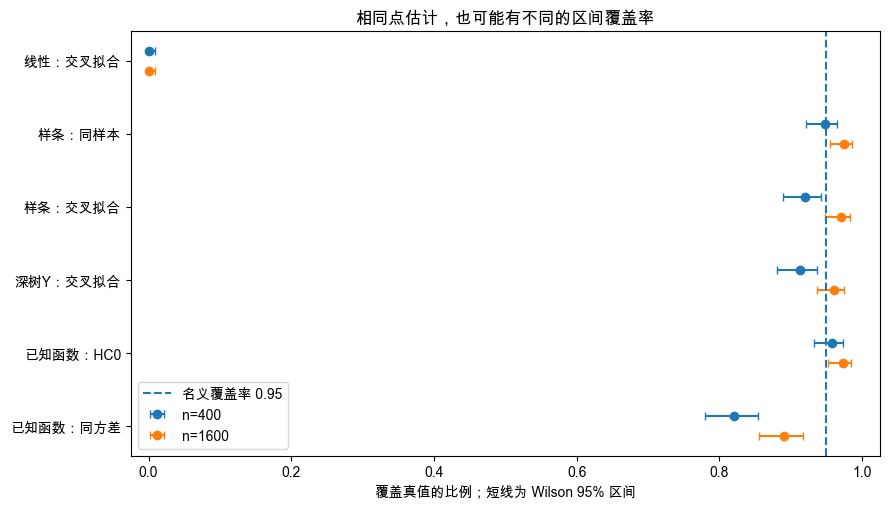

   n       方法  覆盖次数    覆盖率
 400  线性：交叉拟合     0 0.0000
 400   样条：同样本   379 0.9475
 400  样条：交叉拟合   368 0.9200
 400 深树Y：交叉拟合   365 0.9125
 400 已知函数：HC0   383 0.9575
 400 已知函数：同方差   328 0.8200
1600  线性：交叉拟合     0 0.0000
1600   样条：同样本   390 0.9750
1600  样条：交叉拟合   388 0.9700
1600 深树Y：交叉拟合   384 0.9600
1600 已知函数：HC0   389 0.9725
1600 已知函数：同方差   356 0.8900


In [13]:
fig, ax = plt.subplots(figsize=(9, 5.2))
positions = np.arange(len(METHOD_ORDER))
for offset, n in zip(np.linspace(-0.14, 0.14, len(SAMPLE_SIZES)), SAMPLE_SIZES):
    sub = simulation_summary.loc[simulation_summary["n"] == n].set_index("方法").loc[METHOD_ORDER]
    x = sub["覆盖率"].to_numpy()
    err = np.vstack([x-sub["覆盖率下限"].to_numpy(), sub["覆盖率上限"].to_numpy()-x])
    ax.errorbar(x, positions+offset, xerr=err, fmt="o", capsize=3, label=f"n={n}")
ax.axvline(0.95, linestyle="--", label="名义覆盖率 0.95")
ax.set(yticks=positions, yticklabels=METHOD_ORDER, xlim=(-0.025, 1.025),
       xlabel="覆盖真值的比例；短线为 Wilson 95% 区间", title="相同点估计，也可能有不同的区间覆盖率")
ax.invert_yaxis()
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()
print(simulation_summary[["n", "方法", "覆盖次数", "覆盖率"]].to_string(index=False))

样条交叉拟合在 400 人时覆盖 368/400=0.920，在 1,600 人时覆盖 388/400=0.970。较小样本下平均 SE 为 0.063，低于经验 SD 0.069，不能写成“做了交叉拟合就达到 95% 覆盖”。同样本样条在这两个设置下并不更差；本例没有要求交叉拟合逐次战胜一个低复杂度拟合。

已知函数的 HC0 覆盖率为 0.958 和 0.973，同方差版本则为 0.820 和 0.890。已知辅助函数并不消除异方差；把标准误公式用错，仍会使覆盖率降低。反过来，标准误计算正确也不能消除线性学习器的系统性欠拟合。

### 2. 单独观察自身样本过拟合

原书图 9.2（正文第 247 页）对比了不分样本与交叉拟合时的估计分布。下面另设一个更直接、可以逐步加深的例子：$m$ 始终用样条，只有 $\ell$ 改用深度逐渐增加的树。分别计算训练预测残差与折外预测残差。

若不限制树深且每个叶节点只留下一个观察，训练集上的 $\widehat\ell(X_i)=Y_i$，则 $r_{Yi}=0$。只要 $r_T$ 仍有变异，公式会返回 $\widehat\theta=0$、标准误 0。这里没有获得精确的“零效应”，而是把需要研究的结局变化提前拟合没了。

,Y训练RMSE,Y折外RMSE,同样本系数,同样本SE,交叉拟合系数,交叉拟合SE
树深,,,,,,
2,2.3056,2.3858,0.9786,0.0631,0.9739,0.0646
4,1.7830,1.9469,0.9214,0.0515,0.9748,0.0540
8,1.1372,1.9425,0.5607,0.0354,0.9729,0.0525
不限制,0.0000,2.1885,0.0000,0.0000,0.9629,0.0624


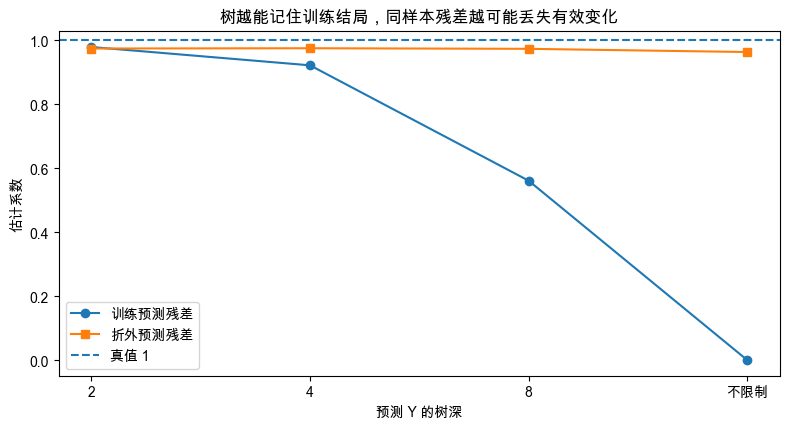

两侧都完全拟合时： 处理残差几乎为零，无法从该残差回归中识别系数。


In [14]:
depths = (2, 4, 8, None)
overfit_rows = []
for depth in depths:
    learner = DecisionTreeRegressor(max_depth=depth, random_state=SEED_LEARNER)
    same_l = learner.fit(X, y).predict(X)
    heldout_l = np.empty(len(y))
    for tr, te in splits:
        heldout_l[te] = clone(learner).fit(X[tr], y[tr]).predict(X[te])
    r_same = plr_score(y, t, same_l, full_m.predict(X))
    r_cf = plr_score(y, t, heldout_l, spline_pred["m"])
    overfit_rows.append({
        "树深": str(depth) if depth is not None else "不限制",
        "Y训练RMSE": np.sqrt(np.mean((y-same_l)**2)),
        "Y折外RMSE": np.sqrt(np.mean((y-heldout_l)**2)),
        "同样本系数": r_same["theta"], "同样本SE": r_same["se"],
        "交叉拟合系数": r_cf["theta"], "交叉拟合SE": r_cf["se"],
    })
overfit_table = pd.DataFrame(overfit_rows).set_index("树深")
display(overfit_table.round(4))
fig, ax = plt.subplots(figsize=(8, 4.4))
p = np.arange(len(depths))
ax.plot(p, overfit_table["同样本系数"], "o-", label="训练预测残差")
ax.plot(p, overfit_table["交叉拟合系数"], "s-", label="折外预测残差")
ax.axhline(truth["theta"], linestyle="--", label="真值 1")
ax.set(xticks=p, xticklabels=overfit_table.index, xlabel="预测 Y 的树深", ylabel="估计系数",
       title="树越能记住训练结局，同样本残差越可能丢失有效变化")
ax.legend()
fig.tight_layout()
plt.show()

# 若两侧都用插值深树，则连分母也消失；不能返回一个貌似有效的数字。
try:
    fit_t = DecisionTreeRegressor(random_state=SEED_LEARNER).fit(X, t)
    plr_score(y, t, same_l, fit_t.predict(X))
except ValueError as exc:
    print("两侧都完全拟合时：", exc)

默认样本中，树深从 2 增加到 8，同样本系数由约 0.979 降至 0.561；不限制深度时变成 0。对应折外系数约为 0.974、0.973 和 0.967。

折外版本不再把每行自己的结局直接减掉，但它仍要承担树的预测误差。前面的重复模拟正是为了区分“去除了这一种过拟合途径”和“整个估计已经足够好”。

### 3. 超参数放在哪里选？

主分析的惩罚事先固定。现在只比较 Ridge 的三个候选惩罚，外层仍为五折，内层使用三折交叉验证。每次内层分割、样条节点估计、标准化和 Ridge 拟合，都只使用当前外层训练折。

这是一种将原书“训练预测器时排除当前留出折”落到软件中的做法。[2，备注 9.4.4；6] 原书第 9.2 节还讨论了利用折外 MSPE 在少数学习器间选择或聚合；本篇不实现那种全局选择，而采用内层调参，避免将两套流程混在一起。

In [15]:
inner_cv = KFold(n_splits=3, shuffle=True, random_state=SEED_INNER)
tuned_learner = GridSearchCV(
    make_spline(), param_grid={"ridge__alpha": [0.1, 1.0, 10.0]},
    scoring="neg_mean_squared_error", cv=inner_cv, n_jobs=1, refit=True,
    error_score="raise",
)
tuned_pred = crossfit_predict(X, y, t, splits, tuned_learner, tuned_learner)
tuned_result = plr_score(y, t, tuned_pred["ell"], tuned_pred["m"])
tuning_rows = []
for k, ((tr, te), (fit_l, fit_m)) in enumerate(zip(splits, tuned_pred["models"])):
    touched = set()
    for inner_tr, inner_te in inner_cv.split(X[tr]):
        # 内层索引是相对于外层训练集的，必须映射回原始行号。
        touched.update(tr[inner_tr].tolist())
        touched.update(tr[inner_te].tolist())
    leaked = len(touched.intersection(te.tolist()))
    assert leaked == 0 and touched == set(tr.tolist())
    tuning_rows.append({"外层折": k+1, "Y所选alpha": fit_l.best_params_["ridge__alpha"],
                        "T所选alpha": fit_m.best_params_["ridge__alpha"],
                        "内层触及人数": len(touched), "触及外层留出人数": leaked})
tuning_table = pd.DataFrame(tuning_rows)
display(tuning_table)
print(f"内层调参后：theta={tuned_result['theta']:.4f}，SE={tuned_result['se']:.4f}")
print("这项结果用于演示调参范围，不根据与真值的距离宣称优于固定惩罚。")

,外层折,Y所选alpha,T所选alpha,内层触及人数,触及外层留出人数
0,1,1.0,10.0,960,0
1,2,0.1,10.0,960,0
2,3,0.1,10.0,960,0
3,4,0.1,10.0,960,0
4,5,0.1,10.0,960,0


内层调参后：theta=1.0388，SE=0.0356
这项结果用于演示调参范围，不根据与真值的距离宣称优于固定惩罚。


### 4. 换一个随机划分，会怎样？

下面固定主数据，只改变分折种子，比较 2、5、10 折。每次重新训练，但没有生成新研究对象。图中的范围只表示这一份数据对所尝试划分的敏感程度；不能用这 20 个数的标准差代替研究的抽样标准误，也不能再除以 $\sqrt{20}$ 当作“精度提高”。

原书备注 9.4.5 对折数给出经验性讨论，并没有一个所有数据通用的最优折数。DoubleML 还提供重复交叉拟合及聚合接口；本篇仅展示划分敏感性，不自行构造聚合置信区间。[2，备注 9.4.5；5]

,最小估计,中位估计,最大估计,划分间SD,平均单次SE
折数,,,,,
2,1.02750,1.05336,1.07023,0.01378,0.03544
5,1.03330,1.04470,1.05399,0.00582,0.03589
10,1.03976,1.04330,1.05231,0.00352,0.03593


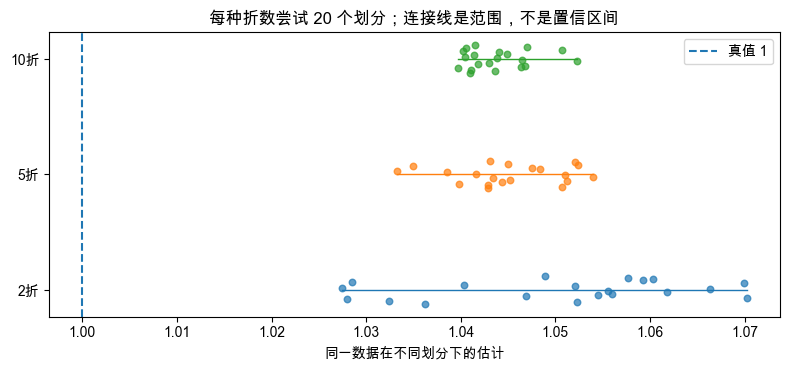

In [16]:
resplit_rows = []
for k in (2, 5, 10):
    for r in range(N_RESPLITS):
        local_splits = make_splits(len(main), k, SEED_RESPLIT+r)
        pr = crossfit_predict(X, y, t, local_splits, make_spline(), make_spline())
        est = plr_score(y, t, pr["ell"], pr["m"])
        resplit_rows.append({"折数": k, "划分": r+1, "估计": est["theta"], "SE": est["se"]})
resplit = pd.DataFrame(resplit_rows)
resplit_summary = resplit.groupby("折数").agg(
    最小估计=("估计", "min"), 中位估计=("估计", "median"), 最大估计=("估计", "max"),
    划分间SD=("估计", "std"), 平均单次SE=("SE", "mean"),
)
display(resplit_summary.round(5))
fig, ax = plt.subplots(figsize=(8, 3.8))
for j, k in enumerate((2, 5, 10)):
    values = resplit.loc[resplit["折数"] == k, "估计"].to_numpy()
    ax.scatter(values, j+np.linspace(-0.12, 0.12, len(values)), s=22, alpha=0.7)
    ax.plot([values.min(), values.max()], [j, j], linewidth=1)
ax.axvline(truth["theta"], linestyle="--", label="真值 1")
ax.set(yticks=[0, 1, 2], yticklabels=["2折", "5折", "10折"], xlabel="同一数据在不同划分下的估计",
       title=f"每种折数尝试 {N_RESPLITS} 个划分；连接线是范围，不是置信区间")
ax.legend()
fig.tight_layout()
plt.show()

## 练习

### 练习一：能把每折的系数直接平均吗？

回到 12 行小表。分别计算各折的分子 $B_k=\sum_{i\in I_k}r_{Ti}r_{Yi}$ 和分母 $A_k=\sum_{i\in I_k}r_{Ti}^2$，再比较“各折系数的简单平均”和“合并残差后的系数”。

<details>
<summary>展开推导</summary>

只要各折分母非零，$\widehat\theta_k=B_k/A_k$，因此

$$
\widehat\theta_{\mathrm{pooled}}
=\frac{\sum_k B_k}{\sum_k A_k}
=\sum_k\frac{A_k}{\sum_j A_j}\widehat\theta_k.
$$

权重是各折的处理残差平方和占比，不是每折人数占比。即使人数相等，$A_k$ 也未必相等。这是对第 9.2 节合并矩方程的代数核对，不意味着其他折间聚合算法一概错误；只是有限样本下并非同一个计算。

</details>

In [17]:
fold_rows = []
for k, (_, te) in enumerate(small_splits):
    A = np.sum(small_result["r_t"][te]**2)
    B = np.sum(small_result["r_t"][te]*small_result["r_y"][te])
    fold_rows.append({"折": k+1, "人数": len(te), "A": A, "B": B, "折内系数": B/A})
fold_estimators = pd.DataFrame(fold_rows)
fold_estimators["合并权重"] = fold_estimators["A"]/fold_estimators["A"].sum()
pooled_from_folds = np.sum(fold_estimators["合并权重"]*fold_estimators["折内系数"])
simple_average = fold_estimators["折内系数"].mean()
np.testing.assert_allclose(pooled_from_folds, small_result["theta"], atol=1e-12)
display(fold_estimators.round(6))
print(f"简单平均 = {simple_average:.6f}")
print(f"按残差平方和加权 = {pooled_from_folds:.6f}")
print(f"直接合并所有残差 = {small_result['theta']:.6f}")

,折,人数,A,B,折内系数,合并权重
0,1,4,2.820658,5.932373,2.103188,0.270790
1,2,4,4.165120,8.421843,2.021993,0.399861
2,3,4,3.430638,7.537095,2.196995,0.329349


简单平均 = 2.107392
按残差平方和加权 = 2.101617
直接合并所有残差 = 2.101617


### 练习二：暴露几乎可以被完全预测，是好事吗？

把生成式改为 $T=m_0(X)+\sigma_VV_0$，其他机制不变。比较 $\sigma_V=1,0.5,0.25,0.1$。为隔离问题，先使用完全已知的辅助函数；然后只给 $m_0$ 加一项固定误差 $b(X)=0.15\sqrt{3}X_1/2$，仍使用正确的 $\ell_0$。

<details>
<summary>展开分析</summary>

本例 $\operatorname{Var}(X_1)=4/3$，所以 $E[b^2]=0.15^2$。前面的总体得分展开给出这个固定错误预测器的极限系数：

$$
\theta^*=
\theta_0-\frac{\theta_0 E[b^2]}{\sigma_V^2+E[b^2]}
=\frac{\theta_0\sigma_V^2}{\sigma_V^2+0.15^2}.
$$

$\sigma_V$ 越小，同一项辅助误差相对剩余暴露变化就越大。即使辅助函数完全正确，有限样本的标准误也会因为剩余变异少而变大。$\sigma_V=0$ 时，$T$ 完全由 $X$ 确定，残差系数不再被这套矩方程唯一识别。[2，定理 9.2.1、定义 9.4.1；本式为教学推导]

</details>

In [18]:
weak_rows = []
for sigma_v in (1.0, 0.5, 0.25, 0.1):
    weak_data, weak_truth = generate_data(N_WEAK, SEED_WEAK, treatment_noise=sigma_v)
    yy, tt = weak_data["Y"].to_numpy(), weak_data["T"].to_numpy()
    h = np.sqrt(3)*weak_data["X1"].to_numpy()/2
    exact = plr_score(yy, tt, weak_truth["ell"], weak_truth["m"])
    perturbed = plr_score(yy, tt, weak_truth["ell"], weak_truth["m"]+0.15*h)
    weak_rows.append({"暴露噪声尺度": sigma_v, "已知函数Q": exact["q"],
                      "已知函数估计": exact["theta"], "已知函数SE": exact["se"],
                      "m有固定误差时估计": perturbed["theta"],
                      "错误函数总体极限": sigma_v**2/(sigma_v**2+0.15**2)})
weak_table = pd.DataFrame(weak_rows)
display(weak_table.round(5))
zero_data, zero_truth = generate_data(200, SEED_WEAK, treatment_noise=0.0)
try:
    plr_score(zero_data["Y"].to_numpy(), zero_data["T"].to_numpy(),
              zero_truth["ell"], zero_truth["m"])
except ValueError as exc:
    print("没有剩余暴露变异时：", exc)

,暴露噪声尺度,已知函数Q,已知函数估计,已知函数SE,m有固定误差时估计,错误函数总体极限
0,1.00,0.99202,0.99922,0.02018,0.97454,0.97800
1,0.50,0.24800,0.99843,0.04037,0.90694,0.91743
2,0.25,0.06200,0.99686,0.08074,0.70693,0.73529
3,0.10,0.00992,0.99215,0.20184,0.24744,0.30769


没有剩余暴露变异时： 处理残差几乎为零，无法从该残差回归中识别系数。


默认结果中，暴露噪声尺度从 1 降到 0.1，已知函数的标准误由约 0.020 增到 0.202；同一项 m 误差对应的总体极限则由 0.978 降到 0.308。预测 T 很准与能够估计 T 的作用，不是同一个目标。

## 总结与适用范围

这一篇真正增加的是交叉拟合：预测每一行时，不让该行参与相应辅助模型的训练。可检查的过程是分折索引、两列折外预测、两列残差、逐行得分，最后才是一个系数和标准误。

正交得分降低小的辅助估计误差的一阶影响；交叉拟合隔开自身样本噪声；合适的学习器控制剩余逼近与预测误差。三者缺一项，都不能只凭“运行了 DML”就相信结果。深树训练残差、线性欠拟合和同方差区间的对照，分别展示了不同的失败原因。

部分线性模型适合用一个加性斜率概括暴露作用的场景。它不会自动产生个体效应；也不会因用了随机森林，就消除恒定斜率这一限制。二元处理、任意效应异质性与总体 ATE 的衔接，留到下一份 IRM 笔记。

本篇按独立同分布观察计算标准误。纵向记录、医院聚类或家庭聚类不能直接按这里逐行随机分折并套用独立样本标准误。还要事先确定处理前调整变量、目标人群与可相信的识别条件，这些要求和前十篇没有改变。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. 上传版本 arXiv:2305.18793v2，2023-10-03。附录 B.3：线性 FWL 定理。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传文件 `CausalML_book_2022.pdf`，实际扉页版本为 0.1.2，2026-05-03。第 9.2 节（正文 239–247 页）：PLM、残差化、交叉拟合、辅助预测质量与图 9.1、9.2；第 9.4 节（正文 261–268 页）：正交得分、通用算法与强识别。公式中的符号按本文约定统一，教学数据与参数另行给出。

[3] DoubleML 官方文档：[`DoubleMLPLR`](https://docs.doubleml.org/stable/api/generated/doubleml.plm.DoubleMLPLR.html)。对应 `ml_l`、`ml_m`、`partialling out` 与指定样本划分接口。

[4] DoubleML 官方文档：[Score functions](https://docs.doubleml.org/stable/guide/scores.html) 与 [Variance estimation and confidence intervals](https://docs.doubleml.org/stable/guide/se_confint.html)。软件采用 $\psi_a\theta+\psi_b$ 的记法；本文只核对单次划分下的 PLR 得分和区间。

[5] DoubleML 官方文档：[Sample-splitting, cross-fitting and repeated cross-fitting](https://docs.doubleml.org/stable/guide/resampling.html)。外部指定分折与重复分折的区别。本篇没有把划分间标准差当作抽样标准误。

[6] scikit-learn 官方文档：[SplineTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html) 与 [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)。用于实现加性样条与折内预处理；不是两本书原始模拟的默认学习器。